# TX

### Define Coding and Modulation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from typing import Tuple

class SatelliteTX:
    """
    Satellite Transmitter Baseband Processor.

    This class handles the conversion of text data into a baseband
    complex signal ready for RF up-conversion or analog simulation.

    Attributes:
        symbol_rate (int): Number of symbols transmitted per second (Baud rate).
        sps (int): Samples per symbol (Oversampling factor).
        fs (int): System sampling rate in Hz.
        alpha (float): Roll-off factor for the Root Raised Cosine filter.
    """

    def __init__(self, symbol_rate: int = 10000, sps: int = 8, alpha: float = 0.35):
        self.symbol_rate = symbol_rate
        self.sps = sps
        self.fs = symbol_rate * sps
        self.alpha = alpha

    def text_to_bits(self, text: str) -> np.ndarray:
        """
        Convert an ASCII string into a stream of binary bits.
        Each character is represented by 8 bits (MSB first).
        """
        bits = []
        for char in text:
            bits.extend([int(b) for b in format(ord(char), '08b')])
        return np.array(bits)

    def bits_to_qpsk(self, bits: np.ndarray) -> np.ndarray:
        """
        Map a bit stream to complex QPSK symbols using Gray coding.
        """
        if len(bits) % 2 != 0:
            bits = np.append(bits, 0)
        reshaped = bits.reshape(-1, 2)
        symbols = []
        for b in reshaped:
            i = 1.0 if b[0] == 0 else -1.0
            q = 1.0 if b[1] == 0 else -1.0
            symbols.append(complex(i, q) / np.sqrt(2))
        return np.array(symbols)

    def _generate_rrc_taps(self, num_symbols: int = 10) -> np.ndarray:
        """Generate the impulse response (taps) for the Root Raised Cosine filter."""
        T = 1.0 / self.symbol_rate
        t = np.arange(-num_symbols * T, num_symbols * T + 1/self.fs, 1/self.fs)
        taps = np.zeros(len(t))
        for idx, ti in enumerate(t):
            if ti == 0.0:
                taps[idx] = 1.0 - self.alpha + (4 * self.alpha / np.pi)
            elif abs(ti) == T / (4 * self.alpha):
                taps[idx] = (self.alpha / np.sqrt(2)) * (((1 + 2/np.pi) * np.sin(np.pi/(4 * self.alpha))) + ((1 - 2/np.pi) * np.cos(np.pi/(4 * self.alpha))))
            else:
                num = np.sin(np.pi * ti / T * (1 - self.alpha)) + 4 * self.alpha * ti / T * np.cos(np.pi * ti / T * (1 + self.alpha))
                den = np.pi * ti / T * (1 - (4 * self.alpha * ti / T)**2)
                taps[idx] = num / den
        return taps / np.sqrt(np.sum(taps**2))

    def apply_rrc_filter(self, symbols: np.ndarray) -> np.ndarray:
        """Perform pulse shaping on the QPSK symbols."""
        upsampled = np.zeros(len(symbols) * self.sps, dtype=complex)
        upsampled[::self.sps] = symbols
        taps = self._generate_rrc_taps()
        tx_signal = np.convolve(upsampled, taps, mode='same')
        return tx_signal

    def export_to_csv(self, signal: np.ndarray, filename_i: str = "V_I.csv", filename_q: str = "V_Q.csv") -> None:
        """
        Export the complex signal's I and Q components to separate CSV files.
        Each file contains 'Time (s)' and the corresponding 'I' or 'Q' voltage values.
        """
        time_axis = np.arange(len(signal)) / self.fs

        df_i = pd.DataFrame({
            'Time': time_axis,
            'I': signal.real
        })
        df_i.to_csv(filename_i, index=False)
        print(f"[System Info] I-channel signal exported successfully to {filename_i}")

        df_q = pd.DataFrame({
            'Time': time_axis,
            'Q': signal.imag
        })
        df_q.to_csv(filename_q, index=False)
        print(f"[System Info] Q-channel signal exported successfully to {filename_q}")

### DSP Chain

In [2]:
# 1. Initialize and execute the DSP chain
tx = SatelliteTX(symbol_rate=10000, sps=8, alpha=0.35)
test_str = "Hello LEO Satellite!"

bits = tx.text_to_bits(test_str)
symbols = tx.bits_to_qpsk(bits)
signal = tx.apply_rrc_filter(symbols)

print("DSP chain processing complete.")

DSP chain processing complete.


### Plotting

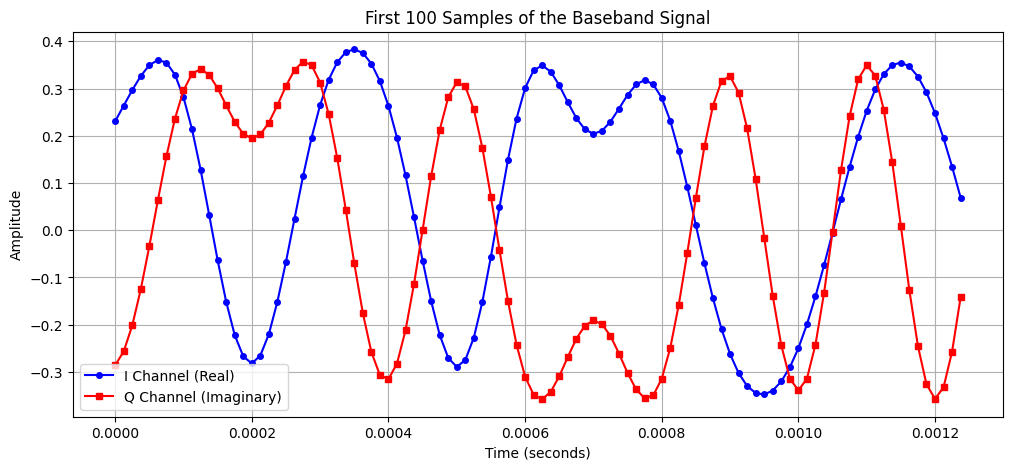

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# 2. Plotting: Visualize the first 100 samples against time
n_samples = 100
# Calculate time array for the x-axis (t = index / fs)
time_axis = np.arange(n_samples) / tx.fs

plt.figure(figsize=(12, 5))
plt.plot(time_axis, signal.real[:n_samples], 'b-o', label='I Channel (Real)', markersize=4)
plt.plot(time_axis, signal.imag[:n_samples], 'r-s', label='Q Channel (Imaginary)', markersize=4)

plt.title(f'First {n_samples} Samples of the Baseband Signal')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

Displaying TX Signal Spectrum...


/tmp/ipykernel_2029/590826155.py:8: UserWarning: nperseg=1024 is greater than signal length max(len(x), len(y)) = 640, using nperseg = 640
  freqs, psd = sp_signal.welch(signal, fs, nperseg=1024, detrend=False, return_onesided=False)


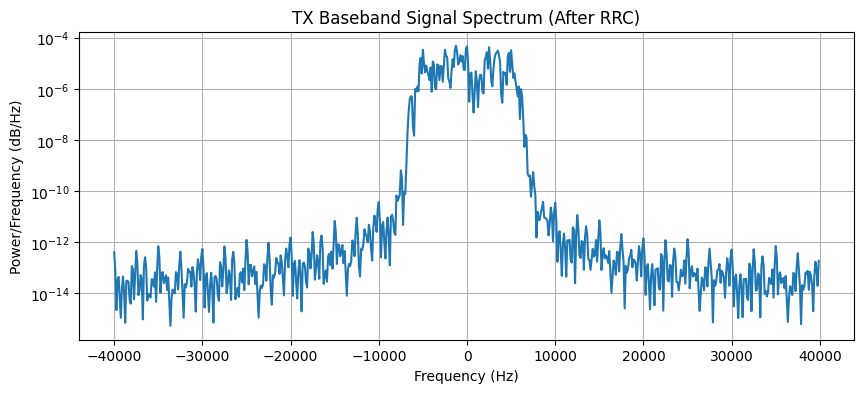

In [8]:
def plot_spectrum(signal: np.ndarray, fs: int, title: str):
    """
    Calculate and plot the Power Spectral Density (PSD) of the signal.
    """
    from scipy import signal as sp_signal

    # Calculate PSD using Welch method
    freqs, psd = sp_signal.welch(signal, fs, nperseg=1024, detrend=False, return_onesided=False)

    # Shift the zero-frequency component to the center
    freqs = np.fft.fftshift(freqs)
    psd = np.fft.fftshift(psd)

    plt.figure(figsize=(10, 4))
    plt.semilogy(freqs, psd)
    plt.title(title)
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Power/Frequency (dB/Hz)')
    plt.grid(True)
    plt.show()

# Visualize TX Spectrum
print("Displaying TX Signal Spectrum...")
plot_spectrum(signal, tx.fs, "TX Baseband Signal Spectrum (After RRC)")

### Save I/Q Data

In [4]:
import os
from google.colab import drive
import pandas as pd

# 3. Export results to Google Drive
drive.mount('/content/drive')
drive_path = '/content/drive/MyDrive/satellite_data'
if not os.path.exists(drive_path):
    os.makedirs(drive_path)

file_path_i = os.path.join(drive_path, 'V_I.csv')
file_path_q = os.path.join(drive_path, 'V_Q.csv')
tx.export_to_csv(signal, filename_i=file_path_i, filename_q=file_path_q)

# Preview the exported data in Google Drive
print(f"Files successfully saved to: {file_path_i} and {file_path_q}")
display(pd.read_csv(file_path_i).head())
display(pd.read_csv(file_path_q).head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[System Info] I-channel signal exported successfully to /content/drive/MyDrive/satellite_data/V_I.csv
[System Info] Q-channel signal exported successfully to /content/drive/MyDrive/satellite_data/V_Q.csv
Files successfully saved to: /content/drive/MyDrive/satellite_data/V_I.csv and /content/drive/MyDrive/satellite_data/V_Q.csv


,Time,I
0,0.000000,0.230747
1,0.000013,0.263801
2,0.000025,0.296669
3,0.000037,0.326546
4,0.000050,0.349387


,Time,Q
0,0.000000,-0.285737
1,0.000013,-0.256537
2,0.000025,-0.201592
3,0.000037,-0.125003
4,0.000050,-0.033721


# Channel

# RX

In [5]:
class SatelliteRX:
    """
    Satellite Receiver Baseband Processor.
    Matches the transmitter chain to recover original bits and text.
    """
    def __init__(self, symbol_rate: int = 10000, sps: int = 8, alpha: float = 0.35):
        self.symbol_rate = symbol_rate
        self.sps = sps
        self.fs = symbol_rate * sps
        self.alpha = alpha

    def _generate_rrc_taps(self, num_symbols: int = 10) -> np.ndarray:
        """Same RRC taps as TX to act as a Matched Filter."""
        T = 1.0 / self.symbol_rate
        t = np.arange(-num_symbols * T, num_symbols * T + 1/self.fs, 1/self.fs)
        taps = np.zeros(len(t))
        for idx, ti in enumerate(t):
            if ti == 0.0:
                taps[idx] = 1.0 - self.alpha + (4 * self.alpha / np.pi)
            elif abs(ti) == T / (4 * self.alpha):
                taps[idx] = (self.alpha / np.sqrt(2)) * (((1 + 2/np.pi) * np.sin(np.pi/(4 * self.alpha))) + ((1 - 2/np.pi) * np.cos(np.pi/(4 * self.alpha))))
            else:
                num = np.sin(np.pi * ti / T * (1 - self.alpha)) + 4 * self.alpha * ti / T * np.cos(np.pi * ti / T * (1 + self.alpha))
                den = np.pi * ti / T * (1 - (4 * self.alpha * ti / T)**2)
                taps[idx] = num / den
        return taps / np.sqrt(np.sum(taps**2))

    def apply_matched_filter(self, rx_signal: np.ndarray) -> np.ndarray:
        """Apply RRC matched filtering to the received signal."""
        taps = self._generate_rrc_taps()
        filtered = np.convolve(rx_signal, taps, mode='same')
        return filtered

    def downsample_and_slice(self, filtered_signal: np.ndarray) -> np.ndarray:
        """
        Downsample by picking the center of the symbol (optimal sampling point).
        In B2B, this is simply at the SPS index.
        """
        # In an ideal system with symmetric RRC taps, the peak is at the center
        symbols = filtered_signal[::self.sps]
        return symbols

    def qpsk_to_bits(self, symbols: np.ndarray) -> np.ndarray:
        """Hard decision slicing for QPSK symbols to bits (Gray coding)."""
        bits = []
        for s in symbols:
            b0 = 0 if s.real > 0 else 1
            b1 = 0 if s.imag > 0 else 1
            bits.extend([b0, b1])
        return np.array(bits)

    def bits_to_text(self, bits: np.ndarray) -> str:
        """Convert bit stream back to ASCII characters."""
        # Trim padding bits if not multiple of 8
        bits = bits[:(len(bits) // 8) * 8]
        reshaped = bits.reshape(-1, 8)
        chars = []
        for b in reshaped:
            char_code = int("".join(map(str, b)), 2)
            chars.append(chr(char_code))
        return "".join(chars)

In [6]:
# End-to-End Test Script (Reading from Drive)
import pandas as pd
import os
import numpy as np

# 1. Setup RX
rx = SatelliteRX(symbol_rate=10000, sps=8, alpha=0.35)
drive_path = '/content/drive/MyDrive/satellite_data'
file_path_i = os.path.join(drive_path, 'V_I.csv')
file_path_q = os.path.join(drive_path, 'V_Q.csv')

# 2. Load IQ data from Google Drive
if os.path.exists(file_path_i) and os.path.exists(file_path_q):
    df_i = pd.read_csv(file_path_i)
    df_q = pd.read_csv(file_path_q)

    # Reconstruct complex signal: I + jQ
    rx_signal = df_i['I'].values + 1j * df_q['Q'].values
    print(f"[System Info] Successfully loaded {len(rx_signal)} samples from Drive.")

    # 3. RX Process
    filtered_signal = rx.apply_matched_filter(rx_signal)
    decision_symbols = rx.downsample_and_slice(filtered_signal)
    rx_bits = rx.qpsk_to_bits(decision_symbols)
    final_text = rx.bits_to_text(rx_bits)

    print(f"Decoded Text from Drive Files: {final_text}")
else:
    print("[Error] Files not found in Drive. Please ensure TX export was successful.")

[System Info] Successfully loaded 640 samples from Drive.
Decoded Text from Drive Files: Hello LEO Satellite!


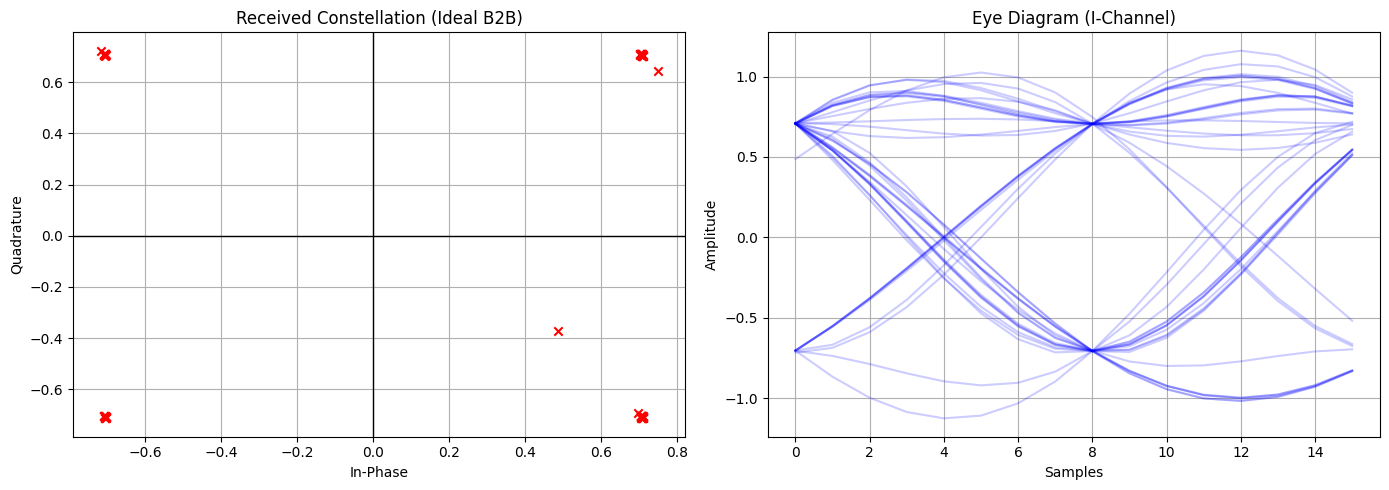

In [7]:
# 5. Visualization: Eye Diagram and Constellation
plt.figure(figsize=(14, 5))

# Constellation Diagram
plt.subplot(1, 2, 1)
plt.scatter(decision_symbols.real, decision_symbols.imag, color='red', marker='x')
plt.title("Received Constellation (Ideal B2B)")
plt.xlabel("In-Phase")
plt.ylabel("Quadrature")
plt.grid(True)
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)

# Eye Diagram (I-Channel)
plt.subplot(1, 2, 2)
eye_samples = rx.sps * 2
for i in range(0, len(filtered_signal) - eye_samples, eye_samples):
    plt.plot(filtered_signal.real[i:i+eye_samples], color='blue', alpha=0.2)
plt.title("Eye Diagram (I-Channel)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()
plt.show()

Displaying RX Signal Spectrum...


/tmp/ipykernel_2029/590826155.py:8: UserWarning: nperseg=1024 is greater than signal length max(len(x), len(y)) = 640, using nperseg = 640
  freqs, psd = sp_signal.welch(signal, fs, nperseg=1024, detrend=False, return_onesided=False)


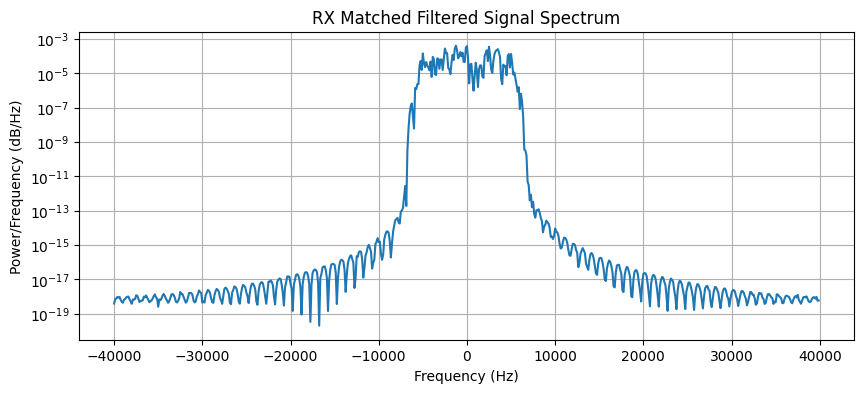

In [9]:
# Visualize RX Spectrum
print("Displaying RX Signal Spectrum...")
plot_spectrum(filtered_signal, rx.fs, "RX Matched Filtered Signal Spectrum")